<a href="https://colab.research.google.com/github/yadavrishikesh/Deep-Learning-Slides-Code/blob/main/code/CNN/CNNs_grayScaleImage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNN) using TensorFlow

In this notebook we will learn:

- What is CNN
- Load image dataset
- Build CNN model
- Train model
- Test accuracy
- Make predictions

We will use MNIST handwritten digits dataset.

Images look like:

- 0,1,2,3,4,5,6,7,8,9
- size = 28 × 28
- grayscale images

In [46]:
# TensorFlow main library
import tensorflow as tf

# Keras high-level API inside TensorFlow
from tensorflow import keras

# Layers used to build CNN
from tensorflow.keras import layers

# plotting
import matplotlib.pyplot as plt

# numerical computation
import numpy as np

## Load Public Dataset (MNIST)

In [47]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Print shapes
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


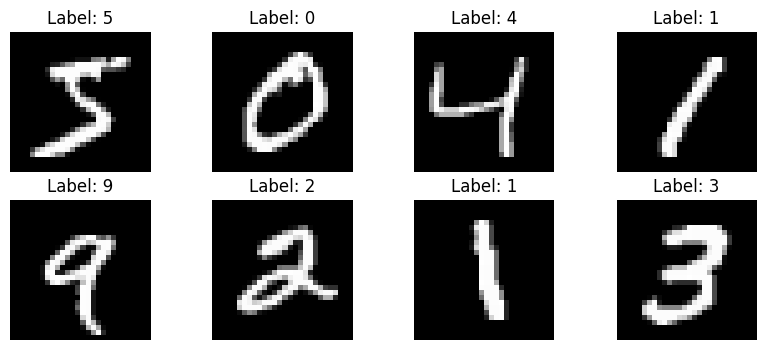

In [48]:
plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()

# Step 1 — Normalize Data

Pixel values range from 0–255. We need to scale them to 0–1. This improves training and avoild any issues of .

In [49]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

## Step 2 — Add Channel Dimension

CNN expects: (batch, height, width, channels), but currently
(60000, 28, 28)

In [50]:
x_train = x_train[..., None]
x_test  = x_test[..., None]

print(x_train.shape)

(60000, 28, 28, 1)


# Step 3 — Build CNN Model

This is the most important part. We build layers one by one.

The CNN model architecture consists of the following layers:

1.  **Conv2D Layer (16 filters, 3x3 kernel, ReLU activation)**:
    *   This is the first convolutional layer, responsible for extracting initial features from the input images.
    *   It uses 16 filters, each with a 3x3 kernel (a small matrix that slides over the image to detect patterns).
    *   The `relu` (Rectified Linear Unit) activation function introduces non-linearity, allowing the model to learn more complex patterns.
    *   `input_shape=(28,28,1)` specifies the expected input dimensions for the first layer (28x28 pixels, 1 channel for grayscale).
    *   **Default `strides=(1, 1)`**: The filter moves 1 pixel at a time horizontally and vertically.
    *   **Default `padding='valid'`**: No padding is applied, meaning the output feature map will be smaller than the input.

2.  **MaxPooling2D Layer (2x2 pool size)**:
    *   This layer performs down-sampling, reducing the spatial dimensions (height and width) of the feature maps.
    *   A `pool_size` of 2x2 means it takes the maximum value from every 2x2 window, effectively reducing the feature map size by half in both dimensions.
    *   **Default `strides=(2, 2)`**: Since `pool_size` is 2x2, `strides` also defaults to 2x2, ensuring non-overlapping pooling windows.
    *   This helps in making the model more robust to small variations in the input and reduces computational cost.

3.  **Conv2D Layer (32 filters, 3x3 kernel, ReLU activation)**:
    *   The second convolutional layer extracts higher-level features from the pooled output of the previous layer.
    *   It uses 32 filters, again with a 3x3 kernel and ReLU activation.
    *   **Default `strides=(1, 1)`**.
    *   **Default `padding='valid'`**.

4.  **MaxPooling2D Layer (2x2 pool size)**:
    *   Another pooling layer further reduces the spatial dimensions of the feature maps.
    *   **Default `strides=(2, 2)`**.

5.  **Flatten Layer**:
    *   Before passing the data to a fully connected neural network, the 2D feature maps are flattened into a 1D vector.
    *   This converts the multi-dimensional output of the convolutional layers into a single long feature vector.

6.  **Dense Layer (128 units, ReLU activation)**:
    *   This is a fully connected (dense) layer with 128 neurons.
    *   It learns complex combinations of the features extracted by the convolutional layers.
    *   ReLU activation is used here as well.

7.  **Dense Layer (10 units, Softmax activation)**:
    *   This is the output layer of the network, with 10 neurons, one for each digit (0-9).
    *   The `softmax` activation function converts the raw outputs (logits) into probabilities, where the sum of probabilities for all 10 digits equals 1.
    *   The digit with the highest probability is the model's prediction.

Mathematically, the output dimensions of a convolutional layer are determined by the input dimensions, kernel size, stride, and padding. Let's denote:

*   `H_in`, `W_in`: Input height and width
*   `F_h`, `F_w`: Kernel (filter) height and width
*   `S_h`, `S_w`: Stride height and width
*   `P_h`, `P_w`: Padding height and width (amount of padding applied to height and width, respectively)
*   `N_f`: Number of filters (kernels)

### Output Height and Width (`H_out`, `W_out`)

The formulas for output height and width depend on the padding type:

#### 1. `padding='valid'` (no padding):

This means `P_h = 0` and `P_w = 0`. The output dimensions are calculated as:

$H_{out} = \lfloor\frac{H_{in} - F_h}{S_h}\rfloor + 1$

$W_{out} = \lfloor\frac{W_{in} - F_w}{S_w}\rfloor + 1$

#### 2. `padding='same'` (output size is approximately same as input, often implies adding padding):

If the padding is chosen such that the output feature map has the same height and width as the input (or as close as possible when strides > 1), the formulas become:

$H_{out} = \lceil\frac{H_{in}}{S_h}\rceil$

$W_{out} = \lceil\frac{W_{in}}{S_w}\rceil$

In this case, the necessary padding `P` (total padding added to one side) is often calculated as: `P = (S * H_in - H_in + F - S) / 2` (for one dimension, assuming `H_in` is divisible by `S`)

### Output Depth (Number of Channels)

The output depth (or number of channels) of a convolutional layer is always equal to the **number of filters** (`N_f`) used in that layer. Each filter produces one feature map.

### Example from our CNN Model (First Conv2D Layer):

*   `H_in = 28`, `W_in = 28`
*   `F_h = 3`, `F_w = 3`
*   `S_h = 1`, `S_w = 1`
*   `padding='valid'` (so `P_h = 0`, `P_w = 0`)
*   `N_f = 16`

Using the formula for `padding='valid'`:

$H_{out} = \lfloor\frac{28 - 3}{1}\rfloor + 1 = 25 + 1 = 26$

$W_{out} = \lfloor\frac{28 - 3}{1}\rfloor + 1 = 25 + 1 = 26$

The output depth will be `N_f = 16`.

So, the output of the first `Conv2D` layer will have dimensions `(26, 26, 16)`.

In [51]:
model = keras.Sequential([

    # First convolution layer
    # 16 filters, kernel size 3x3
    # ReLU activation
    layers.Conv2D(
        filters=16,
        kernel_size=3,
        activation='relu',
        input_shape=(28,28,1),
        strides=(1, 1),
        padding='valid'
    ),

    # Reduce image size
    layers.MaxPooling2D(pool_size=2, strides=(2, 2)),

    # Second convolution layer
    layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu',
        strides=(1, 1),
        padding='valid'
    ),

    # pooling again
    layers.MaxPooling2D(pool_size=2, strides=(2, 2)),

    # flatten to vector
    layers.Flatten(),

    # fully connected layer
    layers.Dense(128, activation='relu'),

    # output layer (10 digits)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


To understand the inner workings of the CNN, we can visualize the convolutional kernels (filters) and the feature maps (activations) generated by these layers.


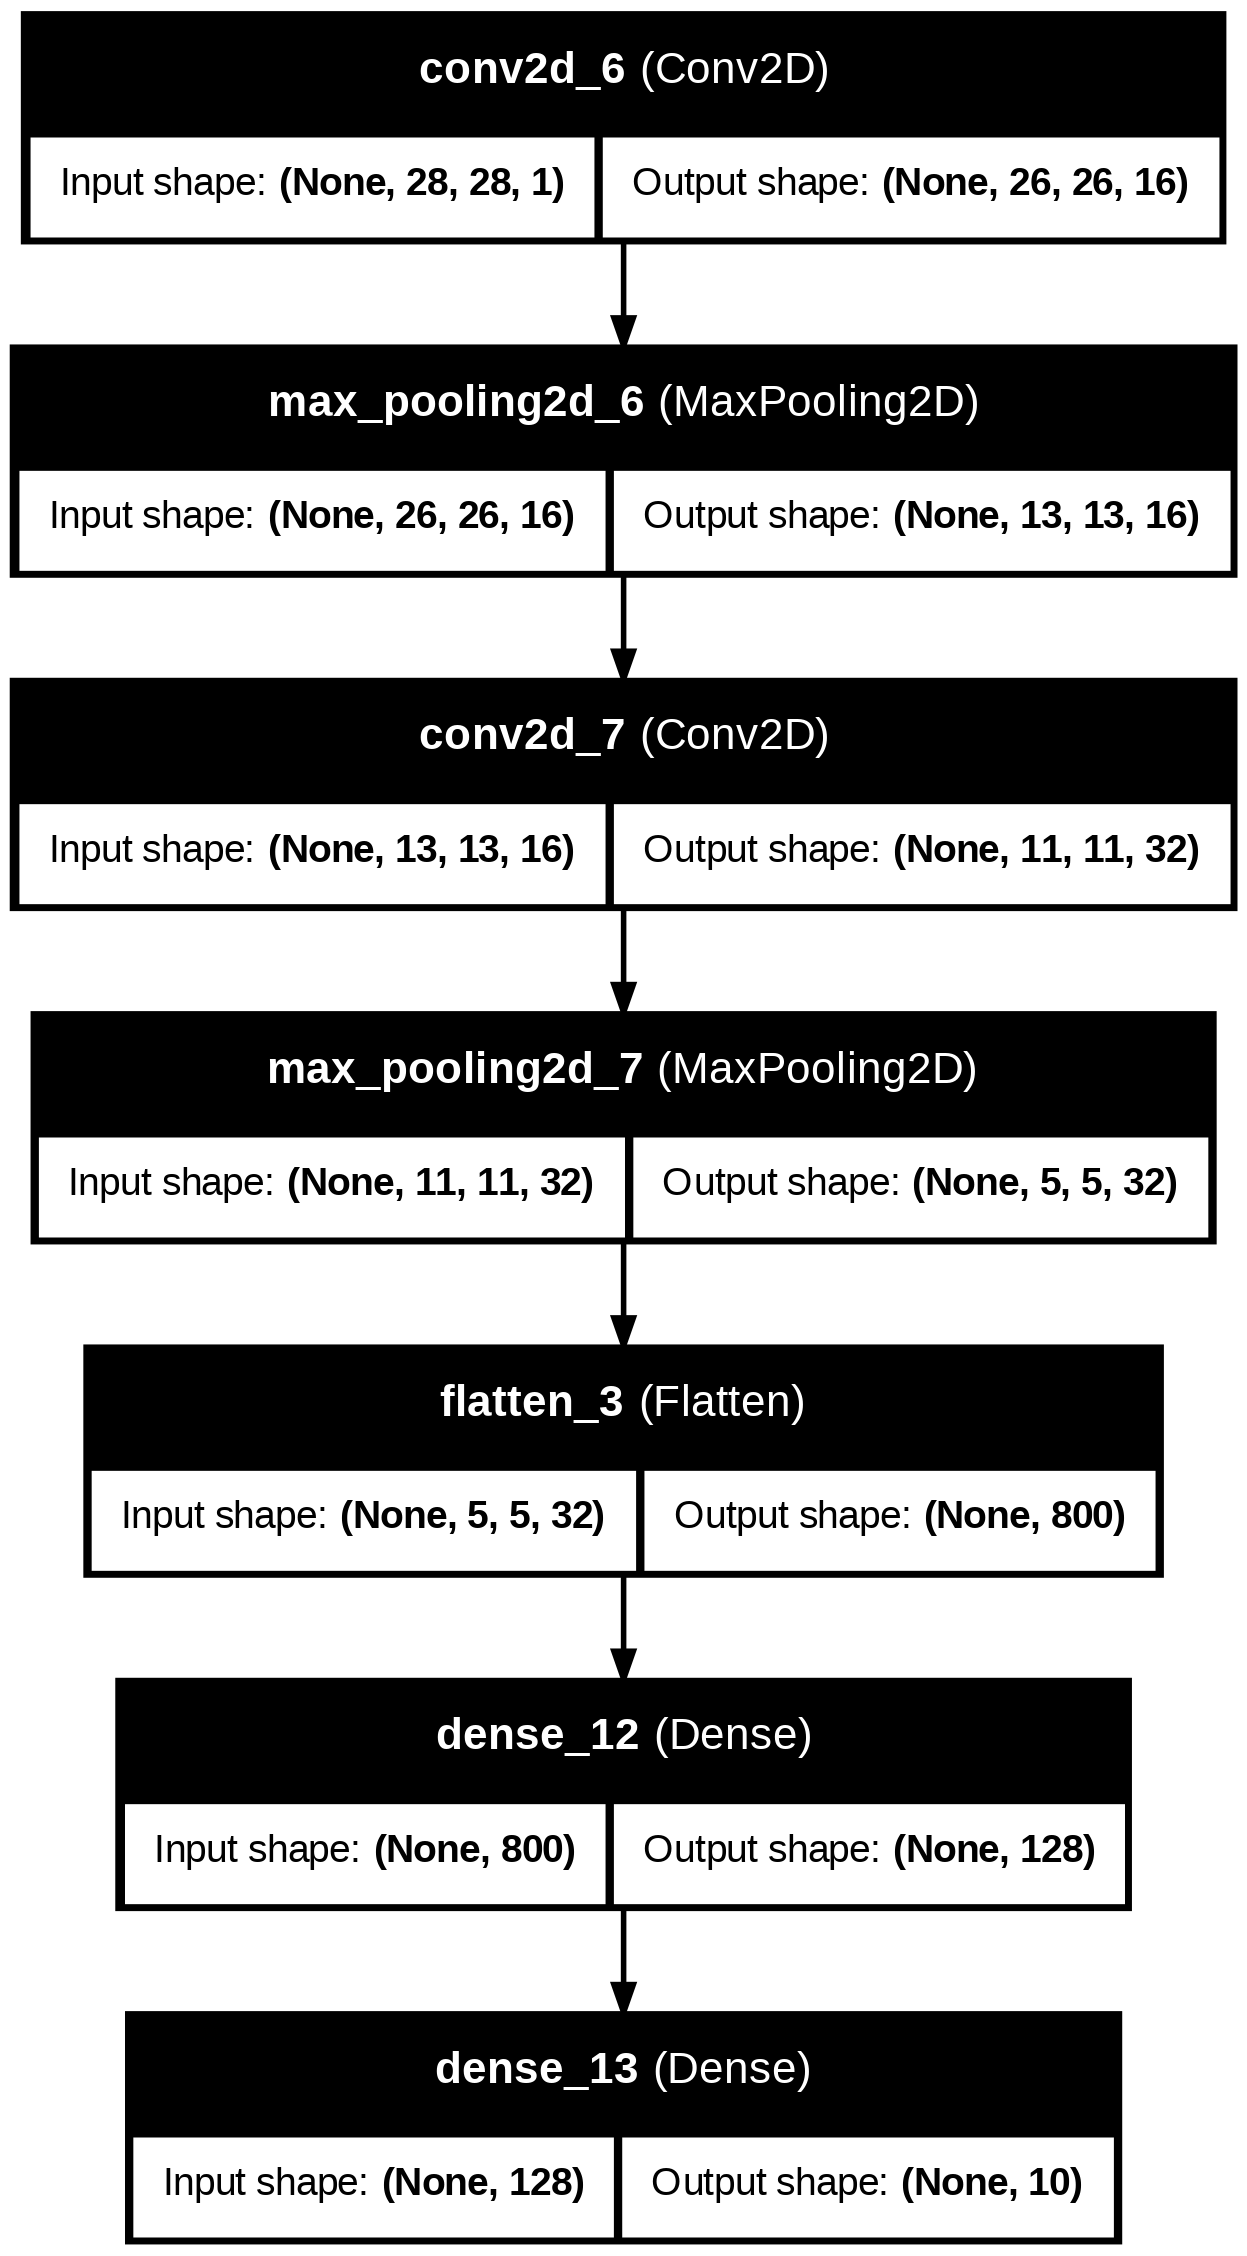

In [52]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='cnn_model.png')

from IPython.display import Image
Image(filename='cnn_model.png')

# Step 4 — Model Summary

This shows architecture. We may observe:

- Conv layers
- pooling layers
- dense layers
- parameters

In [53]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,618 (424.29 KB)

 Trainable params: 108,618 (424.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Compile Model

We define:

- optimizer
- loss
- metrics

In [54]:
model.compile(

    # optimizer updates weights
    optimizer='adam',

    # classification loss
    loss='sparse_categorical_crossentropy',

    # track accuracy
    metrics=['accuracy']
)

# Step 6 — Train Model
 You may see:

- loss decreasing
- accuracy increasing

In [36]:
history = model.fit(

    # training data
    x_train,
    y_train,

    # number of passes
    epochs=5,

    # validation split
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9517 - loss: 0.1622 - val_accuracy: 0.9858 - val_loss: 0.0526
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9836 - loss: 0.0507 - val_accuracy: 0.9868 - val_loss: 0.0447
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9888 - loss: 0.0362 - val_accuracy: 0.9872 - val_loss: 0.0401
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9914 - loss: 0.0269 - val_accuracy: 0.9895 - val_loss: 0.0352
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9934 - loss: 0.0204 - val_accuracy: 0.9882 - val_loss: 0.0416


# Step 7 — Evaluate Model

Test accuracy on unseen data.

In [37]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9862 - loss: 0.0433
Test accuracy: 0.9861999750137329


# Step 8 — Make Predictions

In [38]:
predictions = model.predict(x_test)
np.argmax(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


np.int64(7)

# Step 9 — Show Predictions

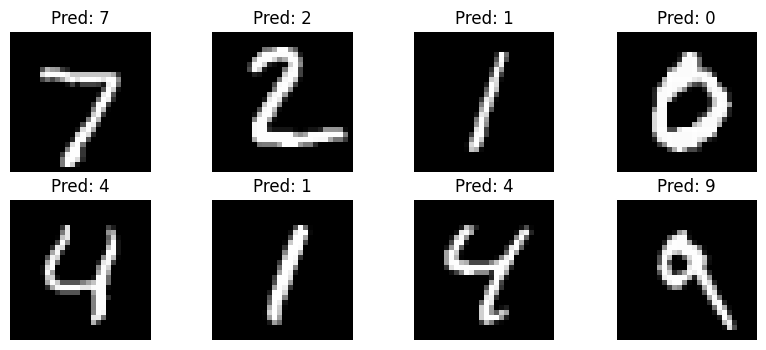

In [39]:
plt.figure(figsize=(10,4))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(x_test[i].squeeze(), cmap='gray')

    pred = np.argmax(predictions[i])

    plt.title("Pred: " + str(pred))

    plt.axis('off')

plt.show()

# Train an MLP on the Same Dataset

Now we train a Multilayer Perceptron (MLP) instead of CNN.

Difference:

CNN uses:

- convolution
- pooling
spatial structure

MLP uses:

- only fully connected layers
- no spatial information


## Step 1 — Prepare Data for MLP

MLP requires flattened input.

- CNN input: (28 × 28 × 1)
- MLP input: 784 vector

So we reshape the data.

In [40]:
# Flatten images for MLP
x_train_mlp = x_train.reshape(-1, 28*28)
x_test_mlp  = x_test.reshape(-1, 28*28)

print(x_train_mlp.shape)

(60000, 784)


# Step 2 — Build MLP Model

This is a simple fully connected neural network.

In [41]:
mlp_model = keras.Sequential([

    # input layer
    layers.Dense(
        128,
        activation='relu',
        input_shape=(784,)
    ),

    # hidden layer
    layers.Dense(
        64,
        activation='relu'
    ),

    # output layer
    layers.Dense(
        10,
        activation='softmax'
    )
])
mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3 — Compile MLP Model

In [42]:
mlp_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

## Step 4 — Evaluate MLP

In [43]:
mlp_loss, mlp_acc = mlp_model.evaluate(
    x_test_mlp,
    y_test
)

print("MLP Test Accuracy:", mlp_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1016 - loss: 2.3217
MLP Test Accuracy: 0.10159999877214432


# Step 5 — Compare CNN vs MLP

In [44]:
print("CNN accuracy :", test_acc)
print("MLP accuracy :", mlp_acc)

CNN accuracy : 0.9861999750137329
MLP accuracy : 0.10159999877214432


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


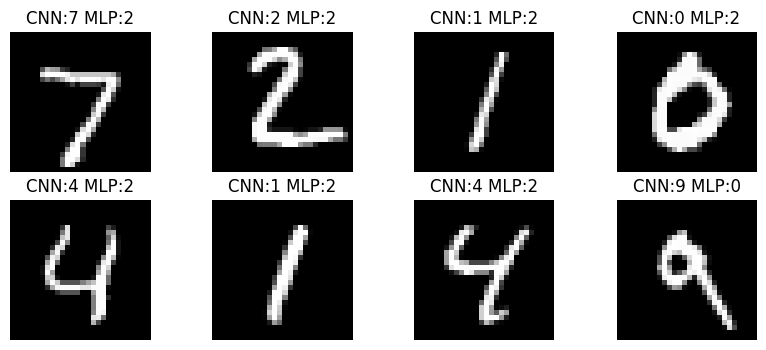

In [45]:
plt.figure(figsize=(10,4))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(x_test[i].squeeze(), cmap='gray')

    pred_cnn = np.argmax(predictions[i])

    pred_mlp = np.argmax(
        mlp_model.predict(
            x_test_mlp[i].reshape(1,-1)
        )
    )

    plt.title(f"CNN:{pred_cnn} MLP:{pred_mlp}")

    plt.axis('off')

plt.show()